<a href="https://colab.research.google.com/github/githubtaniya924/Image-Processing-Projects/blob/main/IP_Practical_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

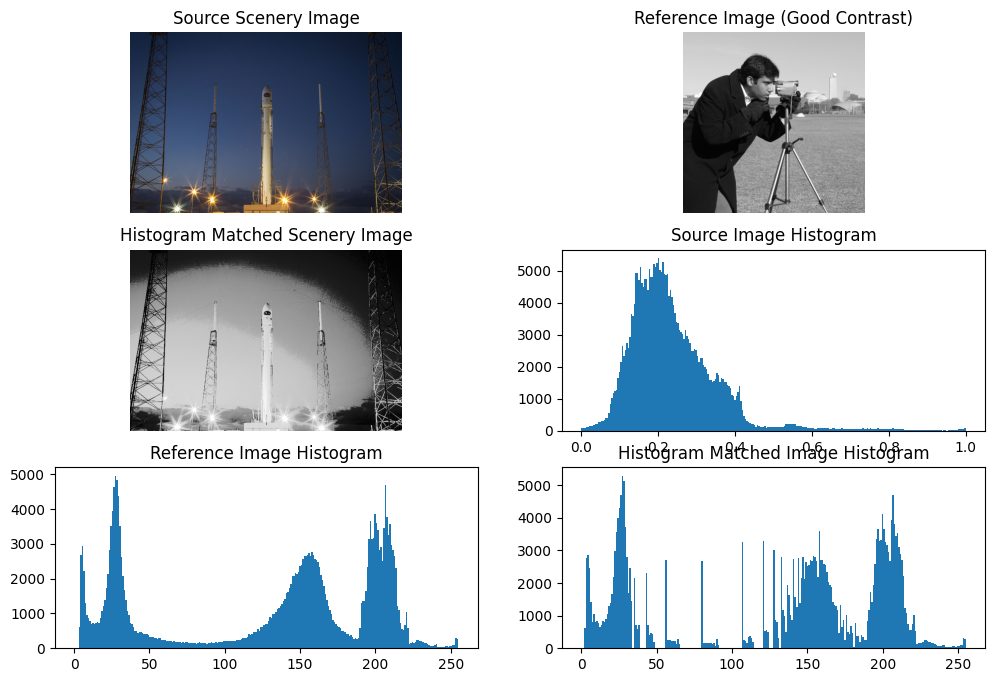

In [4]:
import matplotlib.pyplot as plt
from skimage import data, exposure, color

#load built-in scenery image
source_image = data.rocket()
source_gray = color.rgb2gray(source_image)

reference_image = data.camera()

#apply histogram matching
matched_image = exposure.match_histograms(source_gray, reference_image)

#display images and histogram
plt.figure(figsize=(12, 8))

#source scenery image
plt.subplot(3,2,1)
plt.title("Source Scenery Image")
plt.imshow(source_image, cmap='gray')
plt.axis('off')

#Reference image
plt.subplot(3,2,2)
plt.title("Reference Image (Good Contrast)")
plt.imshow(reference_image, cmap='gray')
plt.axis('off')

#histogram matched image
plt.subplot(3,2,3)
plt.title("Histogram Matched Scenery Image")
plt.imshow(matched_image, cmap='gray')
plt.axis('off')

#histogram of source image
plt.subplot(3,2,4)
plt.hist(source_gray.ravel(), bins=256, range=(0,1))
plt.title("Source Image Histogram")

#reference image
plt.subplot(3,2,5)
plt.hist(reference_image.ravel(), bins=256, range=(0,255))
plt.title("Reference Image Histogram")

#histogram matched image
plt.subplot(3,2,6)
plt.hist(matched_image.ravel(), bins=256, range=(0,255))
plt.title("Histogram Matched Image Histogram")

plt.show()

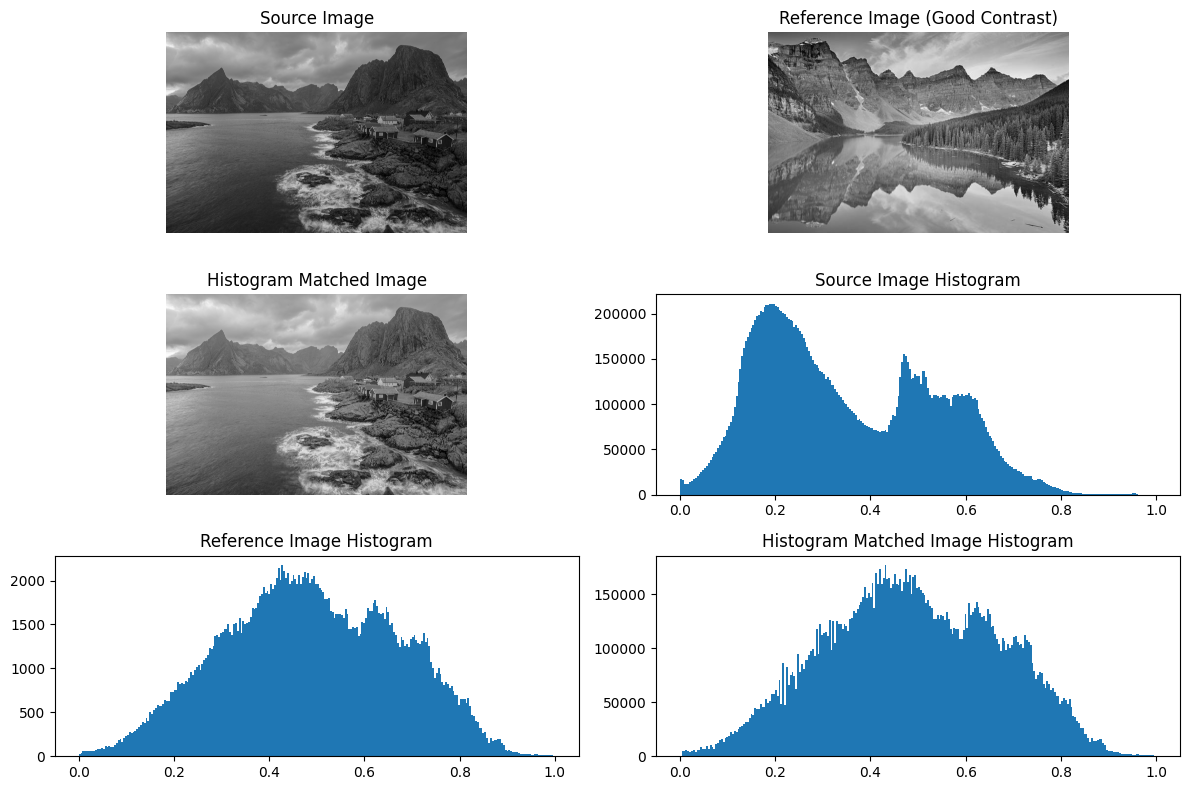

In [18]:
import matplotlib.pyplot as plt
from skimage import exposure, color, io

# Load your own images
source_image = io.imread("source_img1.jpg")
reference_image = io.imread("reference img1.jpg")

# Convert to grayscale
source_gray = color.rgb2gray(source_image)

if reference_image.ndim == 3:
    reference_gray = color.rgb2gray(reference_image)
else:
    reference_gray = reference_image

# Histogram matching
matched_image = exposure.match_histograms(
    source_gray, reference_gray
)

# Display images and histograms
plt.figure(figsize=(12, 8))

# Source image
plt.subplot(3, 2, 1)
plt.title("Source Image")
plt.imshow(source_gray, cmap='gray')
plt.axis('off')

# Reference image
plt.subplot(3, 2, 2)
plt.title("Reference Image (Good Contrast)")
plt.imshow(reference_gray, cmap='gray')
plt.axis('off')

# Matched image
plt.subplot(3, 2, 3)
plt.title("Histogram Matched Image")
plt.imshow(matched_image, cmap='gray')
plt.axis('off')

# Source histogram
plt.subplot(3, 2, 4)
plt.hist(source_gray.ravel(), bins=256, range=(0, 1))
plt.title("Source Image Histogram")

# Reference histogram
plt.subplot(3, 2, 5)
plt.hist(reference_gray.ravel(), bins=256, range=(0, 1))
plt.title("Reference Image Histogram")

# Matched histogram
plt.subplot(3, 2, 6)
plt.hist(matched_image.ravel(), bins=256, range=(0, 1))
plt.title("Histogram Matched Image Histogram")

plt.tight_layout()
plt.show()


**Mean Intensity**
Source → lower or uneven
Reference → desired brightness
Matched → close to reference mean

**Standard Deviation / Variance**
Measures contrast
Matched image std ≈ reference std
Confirms successful histogram matching

**Skewness**
Indicates left/right bias in histogram
Matched image skewness aligns with reference

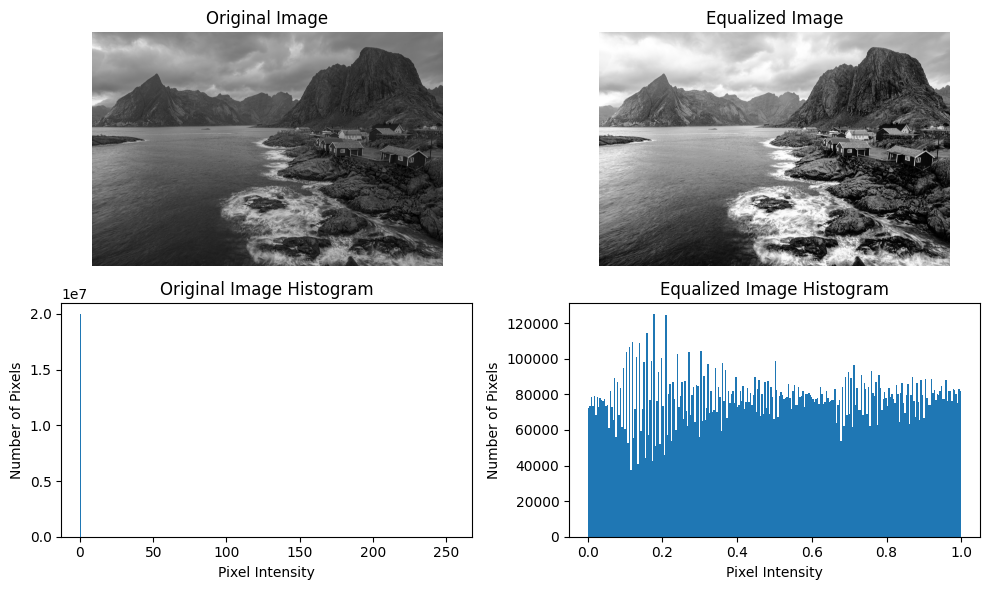

In [13]:
import matplotlib.pyplot as plt
from skimage import data, exposure, io
img=data.moon()
#img=data.grass()
#img=data.gravel()
#img=data.human_mitosis()

image = io.imread("source_img1.jpg")
# Convert to grayscale
img = color.rgb2gray(image)

eq_img= exposure.equalize_hist(img)

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(eq_img, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(img.ravel(), bins=256, range=(0,255))
plt.title("Original Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(2,2,4)
plt.hist(eq_img.ravel(), bins=256, range=(0,1))
plt.title("Equalized Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.tight_layout()

In [23]:
import numpy as np

def stats(image):
    return np.mean(image), np.std(image)

# Statistics for Histogram Matching
mean_src, std_src = stats(source_gray)
mean_ref, std_ref = stats(reference_gray)
mean_match, std_match = stats(matched_image)

# Statistics for Histogram Equalization
mean_eq, std_eq = stats(eq_img)

print("Statistical Metrics Comparison\n")

print("Histogram Matching:")
print(f"Source Image      -> Mean: {mean_src:.4f}, Std Dev: {std_src:.4f}")
print(f"Reference Image   -> Mean: {mean_ref:.4f}, Std Dev: {std_ref:.4f}")
print(f"Matched Image     -> Mean: {mean_match:.4f}, Std Dev: {std_match:.4f}")

print("\nHistogram Equalization:")
print(f"Original Image    -> Mean: {mean_src:.4f}, Std Dev: {std_src:.4f}")
print(f"Equalized Image   -> Mean: {mean_eq:.4f}, Std Dev: {std_eq:.4f}")


Statistical Metrics Comparison

Histogram Matching:
Source Image      -> Mean: 0.3514, Std Dev: 0.1820
Reference Image   -> Mean: 0.4879, Std Dev: 0.1818
Matched Image     -> Mean: 0.4880, Std Dev: 0.1818

Histogram Equalization:
Original Image    -> Mean: 0.3514, Std Dev: 0.1820
Equalized Image   -> Mean: 0.5033, Std Dev: 0.2881
